   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.3/462.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.5 MB/s eta 0:00:00
Mounted at /content/drive
Enter the path to your main folder in Google Drive (e.g., /content/drive/MyDrive/Calcium_Imaging_Data): /content/drive/MyDrive/Try Imaging
Is there optogenetic stimulation? (yes/no, default: yes): 
Enter stimulus start frame (default: 760): 
Enter stimulus duration in frames (default: 250): 

Starting batch processing with the following parameters:
Main folder: /content/drive/MyDrive/Try Imaging
Using optogenetics: True
Stimulus start frame: 760
Stimulus duration: 250


Processing sub-folder: Bend
  Processing image folder: Image 6
Processing image: /content/drive/MyDrive/Try Imaging/Bend/Image 6/potential_asymetrry_bend_type_20230704_182@11A07-LexA_502@LexAoP-CsChr-UAS-GCamp-OK371_retinal_Number1.lif - 1000Hz ch duty 50_ trial 5_register.TIF
A4l
A3l
A2l
A5l
A1l
A7l
A6l
A9r
A8r
A7r
A6r
A5r
A4r
A3r
A2r
A1r


<ipython-input-1-2045483305>:545: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


Hunch


/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


Processing complete for potential_asymetrry_bend_type_20230704_182@11A07-LexA_502@LexAoP-CsChr-UAS-GCamp-OK371_retinal_Number1.lif - 1000Hz ch duty 50_ trial 5_register.TIF
    Successfully processed potential_asymetrry_bend_type_20230704_182@11A07-LexA_502@LexAoP-CsChr-UAS-GCamp-OK371_retinal_Number1.lif - 1000Hz ch duty 50_ trial 5_register.TIF



------------------------------




=== Processing Summary ===
Total images processed: 1
Summary saved to: /content/drive/MyDrive/Try Imaging/processing_summary.csv

Batch processing complete!
Data and figures have been saved in their respective image folders.


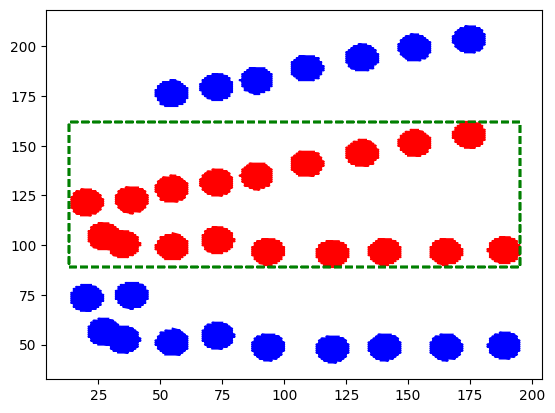

<Figure size 6000x4800 with 0 Axes>

<Figure size 6000x4800 with 0 Axes>

In [1]:
"""

This notebook performs batch processing on calcium imaging data.
It processes all images in a folder structure, each with its associated ROI set.
"""

import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive
import shutil
from numba import jit
from tifffile import imread
import skimage as ski
import skimage.io as skio
import csv
import seaborn as sns
import pandas as pd
from scipy import stats
import zipfile

# Install required packages
!pip install whittaker_eilers roifile
from whittaker_eilers import WhittakerSmoother

!pip install roifile
import roifile
from roifile import roiread


!pip install dtaidistance
from dtaidistance import dtw
from dtaidistance import dtw_visualisation
from dtaidistance import clustering


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Mount Google Drive
drive.mount('/content/drive')


###########################             ###########################
########################### MAIN fUNCTION ###########################
###########################             ###########################

# To apply an ROI mask to your calcium imaging analysis:

# Create a binary mask that marks your regions of interest
# Modify to only process pixels within this mask

#### rois coordinates stored in rois_coordinates

########### OPTMISED + ROI
def DFOF_optimized_roi(image_stack, dict_rois_name_xy,  opto_list):
    total_frame, total_pixel = image_stack.shape[0:2]
    frame_rate = 50
    smooth_frame = 12 * frame_rate // 2  # smooth over 2 seconds


    # strategy for opto-genetics correction: take an ROI of same size outside of image and average it out of all ROI traces
    # opto_list contains True/false to see if there is opto stimulus, stimulus start time in frame number and stimulus duration in frames
    opto_is_used = opto_list[0]

    if opto_is_used == True:
      stimulus_start = opto_list[1]
      stimulus_duration = opto_list[2]


    ### initialise dictionaries to stock information

    dict_rois_df_f = dict()

    dict_rois_baseline = dict()

    dict_rois_df = dict()

    dict_opto_df = dict()

########## loop over every ROI
    # Create a binary mask that marks your regions of interest
    for roi_name, roi_coordinates in dict_rois_name_xy.items():
      #run the function per key and store result in new dictionary
      print(roi_name)

      ############################ make the ROI a disk mask ############################

      # Compute the center of the circle
      center_x = np.mean(roi_coordinates[:, 0])
      center_y = np.mean(roi_coordinates[:, 1])

      # Compute the radius as the maximum distance from the center to the boundary points
      radius = int(np.max(np.linalg.norm(roi_coordinates - [center_x, center_y], axis=1)))
      # Create a coordinate grid for the entire image
      y_indices, x_indices = np.meshgrid(np.arange(total_pixel), np.arange(total_pixel), indexing="ij")

      # Compute the distance from each pixel to the circle center
      distance_from_center = np.sqrt((x_indices - center_x) ** 2 + (y_indices - center_y) ** 2)

      # Create the binary mask (True for pixels inside the circle, False outside)
      roi_mask = distance_from_center <= radius

      # Get indices of pixels inside the ROI
      roi_indices =(np.where(roi_mask))
      # Unpack x and y coordinates for advanced indexing
      roi_y = roi_indices[0].astype(int)
      roi_x = roi_indices[1].astype(int)

      # Pre-allocate arrays with the same shape as image_stack
      pixel_roi = len(roi_x)


    ############################ Optogenetics artifact correction ############################

    # add ROI with center (radius,radius) location as (x,y) so it is in the right corner away from stimulus
    # compute the baseline of ROI (not of individual pixels) and addition of optogenetics --> only take the addition of optogenetics (opto stim signal - baseline)
    # in df_f: f-f0/f0, substract it to f - substract it to df of ROI of interest
    ############################ Optogenetics artifact correction ############################
    ### keep y-coord the same or a multiple of the space between two of the optogenetics stripe
      space_btw_opto_stripes = 16

      # Find the boundaries of the rectangle enclosing all ROIs
      all_roi_coords = np.concatenate(list(dict_rois_name_xy.values()))
      min_x = int(np.min(all_roi_coords[:, 0]))
      max_x = int(np.max(all_roi_coords[:, 0]))
      min_y = int(np.min(all_roi_coords[:, 1]))
      max_y = int(np.max(all_roi_coords[:, 1]))

      ############# make the opto ROI a disk mask #############
      # Calculate opto ROI center outside the rectangle, at the same y-coordinate
    # Translate the original ROI coordinates

      # Usage example
      if opto_is_used:
        # Get image dimensions
        image_height, image_width = total_pixel, total_pixel

        # Place the reference ROI
        opto_roi_x, opto_roi_y = place_reference_roi(
            roi_x, roi_y,
            min_x, max_x, min_y, max_y,
            radius, image_width, image_height,
            space_btw_opto_stripes
        )

        # Visualize the ROIs
        plt.plot(roi_x, roi_y, 'r-')
        plt.plot(opto_roi_x, opto_roi_y, 'b-')
        plt.plot([min_x, max_x, max_x, min_x, min_x], [min_y, min_y, max_y, max_y, min_y], 'g--')


        ### Initialize opto_df with the correct shape
        opto_df = np.zeros((total_frame, (pixel_roi)))  # Shape: (total_frames, num_pixels_in_ROI)

        #print(opto_roi_x, opto_roi_y)
        ##### Calculate baseline for each pixel in the opto ROI
        opto_baseline = np.mean(image_stack[:stimulus_start - 1, opto_roi_y, opto_roi_x], axis=0)



        ##### Compute the df of opto artifact for each pixel
        for frame in range(stimulus_start,stimulus_start+stimulus_duration):
            opto_df[frame, :] = image_stack[frame, opto_roi_y, opto_roi_x] - (opto_baseline)  # Subtract baseline from each pixel

        dict_opto_df[roi_name] = opto_df  # Store pixel-wise opto_df in the dictionary

      elif opto_is_used == False:
        opto_df = np.zeros((total_frame, (pixel_roi)))  # Shape: (total_frames, num_pixels_in_ROI)
        dict_opto_df[roi_name] = opto_df


      ############################ COMPUTE - DF - BASELINE - DF F ############################

      ### initialise arrays
      df = np.zeros((total_frame,pixel_roi))
      df_f = np.zeros((total_frame,pixel_roi))
      baseline = np.zeros((total_frame,pixel_roi))

      ### First section: frames with increasing window sizes
      for frame in range(smooth_frame):
          # Use vectorized percentile computation over all pixels at once
          window = image_stack[:smooth_frame + frame, roi_y, roi_x]
          #print(window.shape)
          baseline[frame] = np.mean(window, axis = 0) ### axis = 0 means in this case along the time series for each individual pixel, not across pixels
          a = image_stack[frame, roi_y, roi_x]
          b = baseline[frame]
  # Use np.less to perform element-wise comparison and np.where to assign values based on the comparison. instead of using an if statement, I've used np.where.    np.less is used to compare the two arrays (image_stack[frame] and baseline[frame]) element-wise. Then np.where assigns a value of 0 where the comparison is True (i.e., where image_stack[frame] is less than baseline[frame]), and assigns the result of image_stack[frame] - baseline[frame] where the comparison is False. This allows for element-wise operations without ambiguity.
          df[frame] = np.where(np.less(image_stack[frame, roi_y, roi_x], baseline[frame]), a - b, image_stack[frame, roi_y, roi_x] - baseline[frame])

          df_f[frame] = df[frame] / baseline[frame]
          # print(f'Frame {frame+1}/{total_frame}')

      # Middle section: frames with full symmetric window
      for frame in range(smooth_frame, total_frame - smooth_frame + 1):
          window = image_stack[frame - smooth_frame:frame + smooth_frame, roi_y, roi_x]
          baseline[frame] = np.mean(window, axis = 0)

          a = image_stack[frame, roi_y, roi_x]
          b = baseline[frame]
          df[frame] = np.where(np.less(image_stack[frame, roi_y, roi_x], baseline[frame]), a - b, image_stack[frame, roi_y, roi_x] - baseline[frame])


          df_f[frame] = df[frame] / baseline[frame]
          #print(f'Frame {frame+1}/{total_frame}')

      # Last section: frames with decreasing window sizes at the end
      for frame in range(total_frame - smooth_frame + 1, total_frame):
          window = image_stack[frame - smooth_frame:total_frame, roi_y, roi_x]
          baseline[frame] = np.mean(window, axis = 0)

          a = image_stack[frame, roi_y, roi_x]
          b = baseline[frame]
          df[frame] = np.where(np.less(image_stack[frame, roi_y, roi_x], baseline[frame]), a - b, image_stack[frame, roi_y, roi_x] - baseline[frame])

          df_f[frame] = df[frame] / baseline[frame]
          #print(f'Frame {frame+1}/{total_frame}')

      df_f[759]=df_f[757] ### artifact at frame 759 corrected by minimal interpolation with previous data point
      df_f[758]=df_f[757]


      dict_rois_df_f[roi_name] = df_f
      dict_rois_baseline[roi_name] = baseline
      dict_rois_df[roi_name] = df

    return dict_rois_baseline, dict_rois_df, dict_rois_df_f, dict_opto_df


def place_reference_roi(roi_x, roi_y, min_x, max_x, min_y, max_y, radius, image_width, image_height, space_btw_opto_stripes, opto_is_used=True):
    """
    Places a reference ROI outside the bounding box of the object for artifact correction.

    Parameters:
    -----------
    roi_x, roi_y : numpy arrays
        Coordinates of the original ROI
    min_x, max_x, min_y, max_y : int
        Bounding box coordinates of the object
    radius : int
        Radius of the ROI
    image_width, image_height : int
        Dimensions of the image
    space_btw_opto_stripes : int
        Space between optogenetic stimulation stripes
    opto_is_used : bool
        Whether optogenetics is used

    Returns:
    --------
    opto_roi_x, opto_roi_y : numpy arrays
        Coordinates of the reference ROI for artifact correction
    """
    if not opto_is_used:
        return roi_x, roi_y

    # Initialize reference ROI coordinates (start with the original ROI)
    opto_roi_x = roi_x.copy()
    opto_roi_y = roi_y.copy()

    # Calculate the center of the original ROI
    center_x = int(np.mean(roi_x))
    center_y = int(np.mean(roi_y))

    # Calculate the center of the bounding box
    bbox_center_x = (min_x + max_x) // 2
    bbox_center_y = (min_y + max_y) // 2

    # Calculate bbox dimensions
    bbox_width = max_x - min_x
    bbox_height = max_y - min_y

    # Safety margin (pixels to stay away from the image edge)
    margin = 20

    # First priority: Try to place the reference ROI horizontally away from the bounding box
    # while keeping the same y-coordinate (for consistent artifact correction)

    # Option 1: Place the reference ROI to the right of the bounding box
    right_x = max_x + radius + 50
    if right_x < image_width - margin:
        # Shift the reference ROI to the right
        x_shift = right_x - center_x
        opto_roi_x = roi_x + x_shift
        return opto_roi_x, opto_roi_y

    # Option 2: Place the reference ROI to the left of the bounding box
    left_x = min_x - radius - 50
    if left_x > margin:
        # Shift the reference ROI to the left
        x_shift = left_x - center_x
        opto_roi_x = roi_x + x_shift
        return opto_roi_x, opto_roi_y

    # If we can't place it horizontally with the same y-coordinate,
    # try placing it vertically with a shifted y-coordinate

    # Option 3: Place the reference ROI above the bounding box
    top_distance = image_height - margin - max_y
    if top_distance > 3 * space_btw_opto_stripes and (roi_y + 3 * space_btw_opto_stripes > max_y + margin).any()  :   ### use and shift_y + roi_y > bboox_y
        # Place reference ROI above the bounding box
        y_shift =   3 * space_btw_opto_stripes
        opto_roi_y = roi_y + y_shift
        return opto_roi_x, opto_roi_y

    # Option 4: Place the reference ROI below the bounding box
    bottom_distance = min_y - margin
    if bottom_distance > 3 * space_btw_opto_stripes and (roi_y - 3 * space_btw_opto_stripes < min_y - margin).any() :

        # Place reference ROI below the bounding box
        y_shift = - 3 * space_btw_opto_stripes
        opto_roi_y = roi_y + y_shift
        return opto_roi_x, opto_roi_y

    # Option 5: If we can't place it nicely, find the corner furthest from the object
    # Define the four corners of the image (with margin)
    corners = [
        (margin, margin),                         # Top-left
        (margin, image_height - margin),          # Bottom-left
        (image_width - margin, margin),           # Top-right
        (image_width - margin, image_height - margin)  # Bottom-right
    ]

    # Find the corner that's furthest from the bounding box center
    max_distance = 0
    best_corner_raw = corners[0]

    for corner in corners:
        distance = ((corner[0] - bbox_center_x) ** 2 + (corner[1] - bbox_center_y) ** 2) ** 0.5
        if distance > max_distance:
            max_distance = distance
            best_corner_raw = corner


    # Shift the reference ROI to the best corner

    # Now, adjust the y-coordinate of the best corner to be a multiple of space_btw_opto_stripes
    target_y = best_corner_raw[1]

    # Find the closest multiple of space_btw_opto_stripes to the target_y
    closest_multiple = round((target_y - center_y)/ space_btw_opto_stripes)

    adjusted_y = roi_y +  closest_multiple * space_btw_opto_stripes

    # Calculate shifts based on the adjusted corner
    x_shift = best_corner_raw[0] - center_x
    y_shift = adjusted_y

    # Apply the shifts to the original ROI coordinates
    opto_roi_x =  roi_x + x_shift
    opto_roi_y =  y_shift

    # # Final safety check: make sure the coordinates are within image bounds with margin
    # opto_roi_x = np.clip(opto_roi_x, margin, image_width - margin - 1) # -1 to stay within bounds
    # opto_roi_y = np.clip(opto_roi_y, margin, image_height - margin - 1) # -1 to stay within bounds

    print(f'CCCC: Placed at adjusted corner ({opto_roi_x.mean():.2f}, {opto_roi_y.mean():.2f})')
    print(f'before ({roi_x.mean():.2f}, {roi_y.mean():.2f})')



    return opto_roi_x, opto_roi_y


def plot_image_overlays(image, overlays, roi_names, save_path=None, **kwargs):
    """Plot image and overlays (bytes) using matplotlib."""
    fig, ax = plt.subplots()
    ax.imshow(image, cmap='plasma')
    if not isinstance(overlays, list):
        overlays = [overlays]

    # Assuming roi_names is a list with the same length as overlays
    for i, overlay in enumerate(overlays):
        roi = overlay
        roi.plot(ax, color='gray', **kwargs)

        # Get ROI center coordinates for text placement
        # Calculate the centroid manually using the coordinates:
        coordinates = roi.coordinates()  # Get coordinates of the ROI
        x_center = np.mean(coordinates[:, 0])  # Calculate mean of x-coordinates
        y_center = np.mean(coordinates[:, 1])  # Calculate mean of y-coordinates

        # Display ROI name as text
        ax.text(x_center, y_center, roi_names[i], color='white')

        ax.axis('off')

    if save_path:
        plt.savefig(save_path)
    plt.close()  # Close the figure to free memory





def process_single_image(image_path, roi_folder_path, output_folder, use_opto=True, stimulus_start=760, stimulus_duration=250):
    """Process a single calcium imaging file with its ROI set"""
    print(f"Processing image: {image_path}")

    # Create specific output folders
    raw_data_folder = os.path.join(output_folder, "Raw Data All Pixels")
    avg_data_folder = os.path.join(output_folder, "Average Data - 1 Pixel per ROI")
    results_folder = os.path.join(output_folder, "Results")

    # Create these folders if they don't exist
    os.makedirs(raw_data_folder, exist_ok=True)
    os.makedirs(avg_data_folder, exist_ok=True)
    os.makedirs(results_folder, exist_ok=True)

    # Load image data
    image_data = ski.io.imread(image_path)
    image_name = os.path.basename(image_path)

    total_frame, total_pixel = image_data.shape[0:2]



    # Set up opto parameters
    temp_use_opto = use_opto

    if image_name.startswith("NO OPTO"):
      temp_use_opto = False

    opto_list = []
    if temp_use_opto:
        opto_list.append(True)
        opto_list.append(stimulus_start)
        opto_list.append(stimulus_duration)
    else:
        opto_list.append(False)

    # Extract ROIs
    rois = []
    rois_coordinates = []
    dict_rois_name_xy = dict()

    # Get list of ROI files
    roi_files = [f for f in os.listdir(roi_folder_path) if f.endswith('.roi')]

    for roi_file in roi_files:
        # Read ROIs 1 by 1 from ROI folder
        roi_path = os.path.join(roi_folder_path, roi_file)
        roi = roiread(roi_path)
        rois.append(roi)
        rois_coordinates.append(roi.coordinates())

        stripped_roi_file = roi_file.replace('.roi', '')

        # Create dictionary that links name to coordinates
        dict_rois_name_xy[stripped_roi_file] = roi.coordinates()

    # Process data
    dict_rois_baseline, dict_rois_df, dict_rois_df_f, dict_opto_df = DFOF_optimized_roi(image_data, dict_rois_name_xy, opto_list)

    roi_names = list(dict_rois_name_xy.keys())

    # Save ROI overlay image if we have frames
    if image_data.shape[0] > 600:  # Check if we have at least 600 frames
        overlay_path = os.path.join(results_folder, f"ROI_overlay_{image_name.replace('.tif', '')}.png")
        plot_image_overlays(image_data[600], rois, roi_names, save_path=overlay_path)

    # Initialize Whittaker smoother for later use
    whittaker_smoother = WhittakerSmoother(
        lmbda=100, order=1, data_length=(dict_rois_df_f[list(dict_rois_df_f.keys())[0]].shape[0])
    )

    # Generate and save trace plots
    # Plot average pixel trace for each ROI in separate subplots
    num_rois = len(dict_rois_name_xy)
    fig, axes = plt.subplots(num_rois, 1, figsize=(10, 6 * num_rois), sharex=True)

    # Ensure axes is always a list even with a single ROI
    if num_rois == 1:
        axes = [axes]

    # Loop through ROIs and plot on respective subplots
    for i, roi_name in enumerate(dict_rois_name_xy):

        dff = dict_rois_df_f[roi_name]
        opto_df = dict_opto_df[roi_name]
        baseline = dict_rois_baseline[roi_name]

        avg_pixel_df_f = np.mean(dff - opto_df/baseline, axis=1)  # Calculate average dff across all pixels for this ROI

        if use_opto:
            axes[i].vlines(stimulus_start, -1, 1, linestyles='dashed', colors='red')
        axes[i].plot(avg_pixel_df_f)  # Plot the average dff trace
        axes[i].set_ylabel('Intensity')
        axes[i].set_title(f'Average Pixel Trace for ROI {roi_name}')
        axes[i].set_ylim(-1, 1)

    # Set common x-axis label for the entire figure
    plt.xlabel('Time Frame')
    plt.tight_layout()  # Adjust spacing to prevent overlap
    traces_path = os.path.join(results_folder, f"Average_Traces_{image_name.replace('.tif', '')}.png")
    plt.savefig(traces_path)
    plt.close()

    # Plot smoothed traces with left/right overlay
    # Generate plot with offset for left and right ROIs
    fig, ax = plt.subplots(figsize=(10, 6), dpi=600)

    # Custom sorting function to prioritize 'T' ROIs
    def sort_roi_names(roi_name):
        if roi_name.startswith('T'):
            return (0, roi_name)  # 'T' ROIs come first
        else:
            return (1, roi_name)  # Other ROIs come after

    sorted_rois_name_xy = sorted(dict_rois_name_xy, key=sort_roi_names)

    offset_height = 0.35  # Define vertical spacing between traces

    # Loop through ROIs and plot with offsets
    for i, roi_name in enumerate(sorted_rois_name_xy):
        if i % 2 == 0:  # Even index (left side ROIs)
            offset = -offset_height * (i)  # Divide by 2 for proper spacing
            color = 'pink'  # Set color to pink for left side
        else:  # Odd index (right side ROIs)
            offset = -offset_height * ((i - 1))  # Divide by 2 for proper spacing
            color = 'gray'  # Set color to gray for right side

        dff = dict_rois_df_f[roi_name]
        baseline = dict_rois_baseline[roi_name]
        opto_df = dict_opto_df[roi_name]

        avg_pixel_df_f = np.mean(dff - opto_df/baseline, axis=1)  # Calculate average dff across all pixels for this ROI
        smoothed_df_f = np.array(whittaker_smoother.smooth(avg_pixel_df_f))

        # Plot the smoothed trace with offset
        ax.plot(smoothed_df_f + offset, color=color)

        # Add text label next to the trace
        ax.text(len(smoothed_df_f), smoothed_df_f[-1] + offset, roi_name, color=color,
                ha='left', va='center')

        # Add a zero line for the current offset
        ax.plot(np.zeros_like(smoothed_df_f) + offset, color='black', linestyle='--', linewidth=0.5, alpha=0.8, zorder=1)

    ax.set_yticks([])
    # Set labels and legend
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('ΔF/F0')
    ax.legend(loc='upper right')
    plt.title('Smoothed Traces with Vertical Offset and Zero Lines')

    smoothed_path = os.path.join(results_folder, f"Smoothed_Traces_{image_name.replace('.tif', '')}.png")
    plt.savefig(smoothed_path)
    plt.close()

    # Calculate correlation matrices
    # Create dictionary of smoothed average traces
    dict_smooth_avg_pixel_df_f = dict()
    # Loop through ROIs
    for roi_name in dict_rois_df_f:
        dff = dict_rois_df_f[roi_name]
        baseline = dict_rois_baseline[roi_name]
        opto_df = dict_opto_df[roi_name]

        avg_pixel_df_f = np.mean(dff - opto_df/baseline, axis=1)  # Calculate average across all pixels
        smoothed_df_f = np.array(whittaker_smoother.smooth(avg_pixel_df_f))
        dict_smooth_avg_pixel_df_f[roi_name] = smoothed_df_f

    # Custom sorting function to prioritize 'T' ROIs
    sorted_roi_names = sorted(dict_rois_name_xy, key=sort_roi_names)

    # Create an empty correlation matrix
    num_rois = len(sorted_roi_names)
    correlation_matrix = np.zeros((num_rois, num_rois))

    # Calculate correlations between all pairs of ROIs (using sorted roi_names)
    for i in range(num_rois):
        for j in range(i + 1, num_rois):  # Avoid redundant calculations
            roi1_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[i]]
            roi2_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[j]]
            correlation, _ = stats.pearsonr(roi1_data, roi2_data)
            correlation_matrix[i, j] = correlation_matrix[j, i] = correlation

    # Create a DataFrame for the correlation matrix
    df_corr = pd.DataFrame(correlation_matrix, index=sorted_roi_names, columns=sorted_roi_names)


    # Plot the correlation matrix
    plt.figure(figsize=(10, 8), dpi=600)
    sns.heatmap(df_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of ROIs (Ordered)')
    plt.tight_layout()

    corr_path = os.path.join(results_folder, f"Correlation_Matrix_{image_name.replace('.tif', '')}.png")
    plt.savefig(corr_path)
    plt.close()

    # Plot clustered correlation matrix
    plt.figure(figsize=(10, 8), dpi=600)
    linkage = sns.clustermap(df_corr, method="average", metric="euclidean",
                             row_cluster=True, col_cluster=True, figsize=(10, 8),
                             cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
    plt.title('Clustered Correlation Matrix of ROIs')
    clustered_corr_path = os.path.join(results_folder, f"Clustered_Correlation_Matrix_{image_name.replace('.tif', '')}.png")
    plt.savefig(clustered_corr_path)
    plt.close()

    # If using optogenetics, calculate correlation matrix during stimulation
    if use_opto:
        correlation_matrix_stim = np.zeros((num_rois, num_rois))

        for i in range(num_rois):
            for j in range(i + 1, num_rois):
                roi1_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[i]][stimulus_start:stimulus_start+stimulus_duration]
                roi2_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[j]][stimulus_start:stimulus_start+stimulus_duration]
                correlation, _ = stats.pearsonr(roi1_data, roi2_data)
                correlation_matrix_stim[i, j] = correlation_matrix_stim[j, i] = correlation

        df_corr_stim = pd.DataFrame(correlation_matrix_stim, index=sorted_roi_names, columns=sorted_roi_names)

        #save corr matrix as a csv file
        corr_csv_path = os.path.join(results_folder, f"Data_Correlation_Matrix_during_stim{image_name.replace('.tif', '')}.csv")
        df_corr.to_csv(corr_csv_path)


        plt.figure(figsize=(10, 8), dpi=600)
        sns.heatmap(df_corr_stim, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
        plt.title('Correlation Matrix of ROIs DURING STIMULATION (Ordered)')
        plt.tight_layout()

        corr_stim_path = os.path.join(results_folder, f"Correlation_Matrix_During_Stim_{image_name.replace('.tif', '')}.png")
        plt.savefig(corr_stim_path)
        plt.close()




        plt.figure(figsize=(10, 8), dpi=600)
        linkage = sns.clustermap(df_corr_stim, method="average", metric="euclidean",
                                 row_cluster=True, col_cluster=True, figsize=(10, 8),
                                 cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
        plt.title('Clustered Correlation Matrix DURING STIMULATION')

        clustered_corr_stim_path = os.path.join(results_folder, f"Clustered_Correlation_Matrix_During_Stim_{image_name.replace('.tif', '')}.png")
        plt.savefig(clustered_corr_stim_path)
        plt.close()

        ###########################             ###########################
        ########################### Classification ###########################
        ###########################             ###########################


        # ── Assume sorted_roi_names is already defined ──
        rois = sorted_roi_names
        prefixes = sorted({roi[:-1] for roi in rois}, key=lambda x: int(x[1:]) if x[1:].isdigit() else x)

        def empty_corr():
            return pd.DataFrame(np.zeros((len(rois), len(rois))), index=rois, columns=rois)

        # ── Define behavioral correlation templates ──

        corr_dfs = {}

        # Crawl: symmetric L-R and adjacent segment coupling
        mat = empty_corr()
        for seg in prefixes:
            mat.loc[f"{seg}l", f"{seg}r"] = mat.loc[f"{seg}r", f"{seg}l"] = 0.9
        for i in range(len(prefixes)-1):
            for side in ['l','r']:
              for second_side in['l','r']:
                a, b = f"{prefixes[i]}{side}", f"{prefixes[i+1]}{side}"
                mat.loc[a, b] = mat.loc[b, a] = 0.8

                a, b = f"{prefixes[i]}{second_side}", f"{prefixes[i+1]}{side}"

                mat.loc[a, b] = mat.loc[b, a] = 0.8
        corr_dfs['Crawl'] = mat

        # Backup: decaying top-down symmetry
        mat = empty_corr()
        decay = np.linspace(1.0, 0.2, len(prefixes))
        for i, seg in enumerate(prefixes):
            mat.loc[f"{seg}l", f"{seg}r"] = mat.loc[f"{seg}r", f"{seg}l"] = decay[i]
            for j in range(i+1, len(prefixes)):
                val = decay[i] * (decay[j]/decay[0]) * 0.5
                mat.loc[f"{seg}l", f"{prefixes[j]}l"] = mat.loc[f"{prefixes[j]}l", f"{seg}l"] = val
                mat.loc[f"{seg}r", f"{prefixes[j]}r"] = mat.loc[f"{prefixes[j]}r", f"{seg}r"] = val
        corr_dfs['Backup'] = mat

        # Hunch: first four segments, symmetric and synchronous
        mat = empty_corr()
        active = prefixes[:4]
        for a in active:
            for b in active:
                mat.loc[f"{a}l", f"{b}r"] = mat.loc[f"{b}r", f"{a}l"] = 0.9
                if a != b :
                  mat.loc[f"{a}l", f"{b}r"] = mat.loc[f"{b}r", f"{a}l"] = 0.8

                  mat.loc[f"{a}l", f"{b}l"] = mat.loc[f"{b}l", f"{a}l"] = 0.8
                  mat.loc[f"{a}r", f"{b}r"] = mat.loc[f"{b}r", f"{a}r"] = 0.8


        corr_dfs['Hunch'] = mat

        # Static Bend Left: active = A1l-A4l, only A4r also partially active
        mat = empty_corr()
        for i in range(len(active)):
            for j in range(i+1, len(active)):
                a, b = f"{active[i]}l", f"{active[j]}l"
                mat.loc[a, b] = mat.loc[b, a] = 0.9


        mat.loc["A4l", "A4r"] = 0.9
        mat.loc["A4r", "A4l"] = 0.9

        corr_dfs['StaticBendLeft'] = mat

        # Static Bend Right: mirror version
        mat = empty_corr()
        for i in range(len(active)):
            for j in range(i+1, len(active)):
                a, b = f"{active[i]}r", f"{active[j]}r"
                mat.loc[a, b] = mat.loc[b, a] = 0.9

        mat.loc["A4l", "A4r"] = 0.9
        mat.loc["A4r", "A4l"] = 0.9
        corr_dfs['StaticBendRight'] = mat

        # Head Cast Left: pairwise correlation among A1l-A3l
        mat = empty_corr()
        active = prefixes[:3]
        for i in range(len(active)):
            for j in range(i+1, len(active)):
                a, b = f"{active[i]}l", f"{active[j]}l"
                mat.loc[a, b] = mat.loc[b, a] = 0.9
        corr_dfs['HeadCastLeft'] = mat

        # Head Cast Right: mirror
        mat = empty_corr()
        for i in range(len(active)):
            for j in range(i+1, len(active)):
                a, b = f"{active[i]}r", f"{active[j]}r"
                mat.loc[a, b] = mat.loc[b, a] = 0.9
        corr_dfs['HeadCastRight'] = mat

        # Stop: no correlation
        corr_dfs['Stop'] = empty_corr()

        # C-Shape Left: Top 3 + Bottom 3 left-side segments highly correlated
        mat = empty_corr()
        left_segments = [f"{prefix}l" for prefix in [prefixes[0], prefixes[1], prefixes[2], prefixes[-3], prefixes[-2], prefixes[-1]]]
        for i in range(len(left_segments)):
            for j in range(i + 1, len(left_segments)):
                a, b = left_segments[i], left_segments[j]
                mat.loc[a, b] = mat.loc[b, a] = 0.9
        corr_dfs['CShapeLeft'] = mat

        # C-Shape Right: same as above, but on right side
        mat = empty_corr()
        right_segments = [f"{prefix}r" for prefix in [prefixes[0], prefixes[1], prefixes[2], prefixes[-3], prefixes[-2], prefixes[-1]]]
        for i in range(len(right_segments)):
            for j in range(i + 1, len(right_segments)):
                a, b = right_segments[i], right_segments[j]
                mat.loc[a, b] = mat.loc[b, a] = 0.9
        corr_dfs['CShapeRight'] = mat

        # Bend Left: stronger and wider head cast (5 segments instead of 3)
        mat = empty_corr()
        active = [f"{prefix}l" for prefix in prefixes[:5]]
        for i in range(len(active)):
            for j in range(i + 1, len(active)):
                mat.loc[active[i], active[j]] = mat.loc[active[j], active[i]] = 0.9
        corr_dfs['BendLeft'] = mat

        # Bend Right: mirror
        mat = empty_corr()
        active = [f"{prefix}r" for prefix in prefixes[:5]]
        for i in range(len(active)):
            for j in range(i + 1, len(active)):
                mat.loc[active[i], active[j]] = mat.loc[active[j], active[i]] = 0.9
        corr_dfs['BendRight'] = mat



        # ── Generate noisy correlation matrices ──

        def make_noisy_samples(corr_df, n_samples=100, noise_sd=0.03, random_state=None):
            rng = np.random.RandomState(random_state)
            base = corr_df.values
            samples = []
            for _ in range(n_samples):
                noise = rng.normal(0, noise_sd, size=base.shape)
                noise = np.triu(noise, k=1)
                noise = noise + noise.T
                mat = base + noise
                np.clip(mat, -1, 1, out=mat)
                mat = (mat + mat.T) / 2
                samples.append(pd.DataFrame(mat, index=rois, columns=rois))
            return samples

        # ── Build full dataset ──
        all_dfs, all_labels = [], []
        for behavior, proto in corr_dfs.items():
            noisy = make_noisy_samples(proto, n_samples=100, noise_sd=0.1, random_state=42)
            all_dfs.extend(noisy)
            all_labels.extend([behavior]*len(noisy))

        def corr_to_features(df):
            m = df.values
            triu = np.triu_indices_from(m, k=1)
            return m[triu]

        X = np.vstack([corr_to_features(df) for df in all_dfs])
        y = np.array(all_labels)

        # ── Train/test split & model ────────────────────────────────
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=0, stratify=y
        )

        clf = RandomForestClassifier(n_estimators=100, random_state=0)
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)


        # CLASSIFICATION  ────────────────────────────────────────────────────────────

        x_new = corr_to_features(df_corr_stim).reshape(1, -1)

        # Predict the label
        pred_label = clf.predict(x_new)[0]
        print(pred_label)

        # Get probabilities
        pred_proba = clf.predict_proba(x_new)[0]

        # Create DataFrame with probabilities
        pred_proba_df = pd.DataFrame(pred_proba.reshape(1, -1), columns=clf.classes_)

        behavior_predictions_path = os.path.join(results_folder, f'{pred_label}_behavior_predictions.txt')

        # Open file and write predictions
        with open(behavior_predictions_path, 'w') as f:
            # Write the predicted behavior as the title
            f.write(f"{pred_label} is Predicted Behavior\n\n")

            # Write probabilities for each behavior
            f.write("Behavior Probabilities:\n")
            for behavior, probability in zip(clf.classes_, pred_proba):
                f.write(f"{behavior}: {probability:.4f}\n")





    ################### Dynamic Time Warping metric ###############################



    a = np.array(np.zeros(total_frame),dtype = float)
    time_series = list(dict_smooth_avg_pixel_df_f.values()) # list of K time series

    time_series.append(a)

    K = len(time_series) # This line is crucial for fixing the error

    # Compute the full pairwise DTW distance matrix
    distance_matrix = dtw.distance_matrix_fast(time_series)

    # Print the full distance matrix
    # print("DTW distance matrix:")
    # print(np.round(distance_matrix, 2))



    distance_matrix_names = sorted_roi_names + ["Zero_series"]


    # Create a Pandas DataFrame for the correlation matrix (using sorted roi_names)
    df_DTW = pd.DataFrame(distance_matrix, index=distance_matrix_names, columns=distance_matrix_names)

    # Plot the correlation matrix using Seaborn heatmap
    plt.figure(figsize=(10, 8))  # Adjust figure size as needed
    sns.heatmap(df_DTW, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
    plt.title('Distance Matrix of ROIs (Ordered)')
    plt.tight_layout()
    distance_path = os.path.join(results_folder, f"Distance_Matrix{image_name.replace('.tif', '')}.png")
    plt.savefig(distance_path)
    plt.close()



    # Clustered ordering based on correlation
    linkage = sns.clustermap(df_DTW, method="average", metric="euclidean", row_cluster=True, col_cluster=True, figsize=(10, 8), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
    plt.title('Clustered Distance Matrix of ROIs')
    clustered_distance_path = os.path.join(results_folder, f"Clustered_Distance_Matrix{image_name.replace('.tif', '')}.png")
    plt.savefig(clustered_distance_path)
    plt.close()

    ############## DURING STIMULATION ###########

    # If using optogenetics, calculate correlation matrix during stimulation
    if use_opto:
      sliced_time_series = [ts[stimulus_start:stimulus_start + stimulus_duration] for ts in time_series]
      distance_matrix = dtw.distance_matrix_fast(sliced_time_series) #############  THIS LINE MIGHT FUCK UP

      # Print the full distance matrix
      # print("DTW distance matrix:")
      # print(np.round(distance_matrix, 2))



      distance_matrix_names = sorted_roi_names + ["Zero_series"]


      # Create a Pandas DataFrame for the correlation matrix (using sorted roi_names)
      df_DTW = pd.DataFrame(distance_matrix, index=distance_matrix_names, columns=distance_matrix_names)

      # Plot the correlation matrix using Seaborn heatmap
      plt.figure(figsize=(10, 8))  # Adjust figure size as needed
      sns.heatmap(df_DTW, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
      plt.title('Distance Matrix of ROIs During Stimulation(Ordered)')
      plt.tight_layout()
      distance_during_stim_path = os.path.join(results_folder, f"Distance_Matrix_During_Stim{image_name.replace('.tif', '')}.png")
      plt.savefig(distance_during_stim_path)
      plt.close()



      # Clustered ordering based on correlation
      linkage = sns.clustermap(df_DTW, method="average", metric="euclidean", row_cluster=True, col_cluster=True, figsize=(10, 8), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
      plt.title('Clustered Distance Matrix of ROIs During Stimulation')
      clustered_distance_path_during_stim = os.path.join(results_folder, f"Clustered_Distance_Matrix_During_Stim{image_name.replace('.tif', '')}.png")
      plt.savefig(clustered_distance_path_during_stim)
      plt.close()







    # Save data as CSV files
    # 1. Save baseline values for all pixels per ROI
    baseline_file = os.path.join(raw_data_folder, f"Baseline_Values_Allpixels_perROIs_{image_name.replace('.tif', '')}.csv")

    with open(baseline_file, "w", newline="") as f:
        header = list(dict_rois_baseline.keys())
        repeated_header = []

        for item in header:
            repeats = (dict_rois_baseline[item].shape)[1]
            repeated_header.extend([item] * repeats)

        w = csv.writer(f)
        w.writerow(repeated_header)

        for i in range(dict_rois_baseline[header[0]].shape[0]):
            row_data = [dict_rois_baseline[roi_name][i,:] for roi_name in header]
            flattened_row_data = [item for sublist in row_data for item in sublist]
            w.writerow(flattened_row_data)

    # 2. Save DF/F0 values for all pixels per ROI
    df_f0_file = os.path.join(raw_data_folder, f"DF_F0_Values_Allpixels_perROIs_{image_name.replace('.tif', '')}.csv")

    with open(df_f0_file, "w", newline="") as f:
        header = list(dict_rois_df_f.keys())
        repeated_header = []

        for item in header:
            repeats = (dict_rois_df_f[item].shape)[1]
            repeated_header.extend([item] * repeats)

        w = csv.writer(f)
        w.writerow(repeated_header)

        for i in range(dict_rois_df_f[header[0]].shape[0]):
            row_data = [dict_rois_df_f[roi_name][i,:] for roi_name in header]
            flattened_row_data = [item for sublist in row_data for item in sublist]
            w.writerow(flattened_row_data)

    # 3. Save average DF/F0 (1 value per ROI)
    dict_avg_pixel_df_f = dict()
    for roi_name in dict_rois_df_f:
        dff = dict_rois_df_f[roi_name]
        opto_df = dict_opto_df[roi_name]
        baseline = dict_rois_baseline[roi_name]
        dict_avg_pixel_df_f[roi_name] = np.mean(dff - opto_df/baseline, axis=1)

    avg_df_f0_file = os.path.join(avg_data_folder, f"Average_DF_F0_Values_1pixel_perROIs_{image_name.replace('.tif', '')}.csv")

    with open(avg_df_f0_file, "w", newline="") as f:
        header = list(dict_rois_baseline.keys())
        w = csv.writer(f)
        w.writerow(header)

        for i in range(dict_avg_pixel_df_f[header[0]].shape[0]):
            row_data = [dict_avg_pixel_df_f[roi_name][i] for roi_name in header]
            w.writerow(row_data)

    # 4. Save smoothed average DF/F0
    smooth_avg_df_f0_file = os.path.join(avg_data_folder, f"Smooth_Average_DF_F0_Values_1pixel_perROIs_{image_name.replace('.tif', '')}.csv")

    with open(smooth_avg_df_f0_file, "w", newline="") as f:
        header = list(dict_rois_baseline.keys())
        w = csv.writer(f)
        w.writerow(header)

        for i in range(dict_smooth_avg_pixel_df_f[header[0]].shape[0]):
            row_data = [dict_smooth_avg_pixel_df_f[roi_name][i] for roi_name in header]
            w.writerow(row_data)

    print(f"Processing complete for {image_name}")



    return {
        "baseline_file": baseline_file,
        "df_f0_file": df_f0_file,
        "avg_df_f0_file": avg_df_f0_file,
        "smooth_avg_df_f0_file": smooth_avg_df_f0_file,
        "overlay_path": overlay_path,
        "traces_path": traces_path,
        "smoothed_path": smoothed_path,
        "corr_path": corr_path,
        "clustered_corr_path": clustered_corr_path
    }

def extract_roi_set(zip_path, extract_folder):
    """Extract ROI set from zip file to specified folder"""
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)
    return extract_folder

def batch_process_folder(main_folder_path, use_opto=True, stimulus_start=760, stimulus_duration=250):
    """
    Process all images in a folder structure

    Folder structure:
    Main Folder/
    ├── Sub Folder 1/
    │   ├── Image 1/
    │   │   ├── image1.tif
    │   │   └── RoiSet.zip
    │   └── Image 2/
    │       ├── image2.tif
    │       └── RoiSet.zip
    └── Sub Folder 2/
        └── ...

    Returns a summary of processed files
    """
    processed_files = []

    # Get all subdirectories in the main folder
    sub_folders = [f.path for f in os.scandir(main_folder_path) if f.is_dir()]

    for sub_folder in sub_folders:
        print(f"Processing sub-folder: {os.path.basename(sub_folder)}")

        # Get all image folders in this subfolder
        image_folders = [f.path for f in os.scandir(sub_folder) if f.is_dir()]

        for image_folder in image_folders:
            print(f"  Processing image folder: {os.path.basename(image_folder)}")

            # Find the TIF image in this folder
            tif_files = [f.path for f in os.scandir(image_folder) if f.path.lower().endswith('.tif')]

            # Find the ROI set zip
            roi_zip = None
            for f in os.scandir(image_folder):
                if f.name.lower() == 'roiset.zip':
                    roi_zip = f.path
                    break

            if not tif_files or not roi_zip:
                print(f"    Missing TIF image or ROI set in {image_folder}, skipping...")
                continue

            # Use the first TIF file found
            image_path = tif_files[0]

            # Create temporary folder for extracted ROIs
            roi_extract_folder = os.path.join(image_folder, 'ROI_temp')
            os.makedirs(roi_extract_folder, exist_ok=True)

            # Extract ROIs
            extract_roi_set(roi_zip, roi_extract_folder)

            try:
                # Process the image
                result = process_single_image(
                    image_path,
                    roi_extract_folder,
                    image_folder,
                    use_opto=use_opto,
                    stimulus_start=stimulus_start,
                    stimulus_duration=stimulus_duration
                )

                # Add to processed files
                processed_files.append({
                    'sub_folder': os.path.basename(sub_folder),
                    'image_folder': os.path.basename(image_folder),
                    'image_file': os.path.basename(image_path),
                    'output_files': result
                })

                print(f"    Successfully processed {os.path.basename(image_path)}")
                print("\n\n")
                print('-' * 30)
                print("\n\n")


            except Exception as e:
                import traceback
                print(f"    Error processing {os.path.basename(image_path)}:")
                traceback.print_exc()  # Print the full traceback
                print(f"    Original error message: {str(e)}")

            # Clean up temporary ROI folder
            shutil.rmtree(roi_extract_folder)

    return processed_files

# Main execution
if __name__ == "__main__":
    # Ask user for main folder path from Google Drive
    main_folder = input("Enter the path to your main folder in Google Drive (e.g., /content/drive/MyDrive/Calcium_Imaging_Data): ")


    # Ask about optogenetics parameters
    use_opto_input = input("Is there optogenetic stimulation? (yes/no, default: yes): ").lower()
    use_opto = False if use_opto_input == "no" else True

    if use_opto:
        stim_start = input("Enter stimulus start frame (default: 760): ")
        stim_start = int(stim_start) if stim_start.isdigit() else 760

        stim_duration = input("Enter stimulus duration in frames (default: 250): ")
        stim_duration = int(stim_duration) if stim_duration.isdigit() else 250
    else:
        stim_start = 760  # Default values even if not used
        stim_duration = 250

    # Print processing information
    print(f"\nStarting batch processing with the following parameters:")
    print(f"Main folder: {main_folder}")
    print(f"Using optogenetics: {use_opto}")
    if use_opto:
        print(f"Stimulus start frame: {stim_start}")
        print(f"Stimulus duration: {stim_duration}")
    print("\n")

    # Process all files in the folder structure
    processed_files = batch_process_folder(
        main_folder_path=main_folder,
        use_opto=use_opto,
        stimulus_start=stim_start,
        stimulus_duration=stim_duration
    )

    # Generate summary
    print("\n=== Processing Summary ===")
    print(f"Total images processed: {len(processed_files)}")

    # Create summary dataframe
    summary_data = []
    for item in processed_files:
        summary_data.append({
            'Sub Folder': item['sub_folder'],
            'Image Folder': item['image_folder'],
            'Image File': item['image_file'],
        })

    summary_df = pd.DataFrame(summary_data)

    # Save summary as CSV
    summary_path = os.path.join(main_folder, "processing_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"Summary saved to: {summary_path}")

    print("\nBatch processing complete!")
    print("Data and figures have been saved in their respective image folders.")#